# Notes from AIMA Chapter 12

# Technical Report: Quantifying Uncertainty in Rational Agent Design

## 1. The Epistemological Necessity of Uncertainty in AI

For millennia, the "laws of thought" tradition—pioneered by Aristotle’s syllogisms—sought to codify irrefutable reasoning patterns. In this logicist tradition, intelligence was synonymous with deductive certainty. However, propositional logic falters when applied to the "open world" of politics, warfare, or daily navigation. These domains are characterized by incomplete information and noisy percepts, rendering deterministic rules like those of arithmetic or chess inapplicable. While logic requires certain knowledge of the world to function, probability serves as its necessary successor.

Probability provides a comprehensive model for rational thought, offering a rigorous mechanism to bridge the gap between raw perceptual information and justified belief. In the Standard Model of AI, we move beyond binary logic toward the rational agent: an entity that maintains degrees of belief to navigate environments where the laws of physics are only partially understood.

---

## 2. Formal Foundations: Random Variables and Sample Spaces

To formalize an agent’s internal state, we define:

* **Random Variables:** aspects of the world whose state is unknown (e.g., Weather or Cavity).
* **Sample Space:** the set of all possible atomic world states.
* **Events:** subsets of the sample space defined by variable assignments.

A discrete probability distribution for a variable $X$ is:

$$
P(X = x_i), \quad \sum_i P(X = x_i) = 1
$$

**Explanation:**
$P(X = x_i)$ means “the probability that variable $X$ takes the specific value $x_i$.”
The summation condition says that if you list every possible value the variable can take, all probabilities must add up to 1. This reflects the idea that *one of those outcomes must occur*.

We distinguish between:

* **Agent function (abstract mapping):**

$$
f : \mathcal{P}^* \rightarrow \mathcal{A}
$$

mapping percept sequences to actions.

**Explanation:**
$\mathcal{P}^*$ represents the sequence of percepts (everything the agent has observed so far). $\mathcal{A}$ represents the set of possible actions. This equation says the agent’s decision process is a function that converts experience into action.

* **Agent program:** the concrete implementation.

Because percept sequences are limited by noisy or partial sensors, the agent can never achieve omniscience. Omniscience requires knowing the true outcome of every action, whereas rationality requires maximizing expected outcomes. Thus, the agent maintains a distribution over possible world states rather than a single certainty.

---

## 3. The Calculus of Probability: Fundamental Laws and Bayes’ Theorem

The evolution of an agent’s belief state follows the core rules of probability.

### 1. Sum Rule (Marginalization)

$$
P(a) = \sum_b P(a, b)
$$

**Explanation:**
$P(a,b)$ is the probability that both $a$ and $b$ are true together.
The summation means: to find the probability of $a$ alone, add up all joint cases where $a$ occurs with every possible value of $b$.
Intuition: *ignore (sum out) the variable you don’t care about.*

---

### 2. Product Rule

$$
P(a, b) = P(a \mid b)P(b)
$$

**Explanation:**
The probability of both events happening equals:

* the probability that $b$ happens, multiplied by
* the probability that $a$ happens *given that* $b$ is already true.

Intuition: *joint probability = prior probability × conditional probability.*

---

### 3. Chain Rule

$$
P(x_1, \dots, x_n) = \prod_{i=1}^{n} P(x_i \mid x_1, \dots, x_{i-1})
$$

**Explanation:**
This expresses a large joint probability as a product of smaller conditional probabilities.
Instead of reasoning about all variables simultaneously, we multiply probabilities one step at a time, each conditioned on what came before.
Intuition: *build the full world probability sequentially.*

---

### Bayes’ Theorem

$$
P(H \mid E) = \frac{P(E \mid H)P(H)}{P(E)}
$$

**Explanation:**

* $H$ = hypothesis (what we want to know)
* $E$ = evidence (what we observed)
* $P(H)$ = prior belief before seeing evidence
* $P(E \mid H)$ = likelihood (how expected the evidence is if the hypothesis were true)
* $P(H \mid E)$ = updated belief (posterior)

Intuition: Bayes’ Rule tells us how to revise beliefs after observing new data.

Bayes’ Rule allows an agent to update a prior belief using perceptual evidence, enabling information-gathering behavior and autonomy.

---

## 4. Structural Representation: Full Joint Distributions and Factorization

The **Full Joint Distribution** assigns probabilities to every atomic event. While complete, its size grows exponentially.

| Number of Boolean Variables ($n$) | Number of Joint States ($2^n$) | Computational/Storage Cost |
| --------------------------------- | ------------------------------ | -------------------------- |
| 10                                | 1,024                          | Negligible                 |
| 20                                | 1,048,576                      | Moderate                   |
| 30                                | 1,073,741,824                  | High                       |
| 100                               | $1.26 \times 10^{30}$          | Intractable                |

**Explanation:**
Each Boolean variable doubles the number of possible worlds (true or false).
Therefore:

$$
\text{Number of states} = 2^n
$$

This exponential growth is the **Curse of Dimensionality**. Factorization reduces complexity by representing the joint distribution as smaller conditional pieces.

---

## 5. The Logic of Inference: From Marginalization to Naive Bayes

Inference extracts answers from probabilistic models via:

* **Marginalization:** summing out hidden variables.
* **Conditioning:** restricting distributions based on evidence.

Example marginalization:

$$
P(Q) = \sum_h P(Q, h)
$$

**Explanation:**
To compute the probability of query variable $Q$, we add the probabilities across all possible values of hidden variable $h$.
Intuition: *consider every hidden possibility, then combine them.*

The **Naive Bayes** model assumes effects are conditionally independent given a cause.

Two common reasoning directions:

* **Diagnostic reasoning:** effects $\rightarrow$ causes
* **Predictive reasoning:** causes $\rightarrow$ effects

---

## 6. Decision Theory: Maximizing Expected Utility

Rational action combines probability with utility. Agents evaluate actions by expected outcomes:

$$
EU(a) = \sum_s P(\text{Result}(a) = s)U(s)
$$

**Explanation:**

* $U(s)$ = utility (how desirable state $s$ is)
* $P(\text{Result}(a)=s)$ = probability that action $a$ leads to state $s$

The equation multiplies desirability by likelihood and adds over all outcomes.

Intuition:
Expected utility is the **probability-weighted average value** of an action.

The **Maximum Expected Utility (MEU)** principle states:

> Choose the action with the highest expected utility.

---

## 7. Conceptual Synthesis: The Rational Agent Pipeline

$$
\text{Belief Representation}
\rightarrow
\text{Belief Update (Bayes)}
\rightarrow
\text{Inference}
\rightarrow
\text{Decision (Utility)}
$$

**Explanation:**
The agent first represents uncertainty, then updates beliefs with evidence, extracts answers through inference, and finally selects actions using utility.

---

## 8. Professor’s Addenda: Mental Models and Conceptual Traps

* **Logic vs Probability:** Probability generalizes logic; certainty (1.0 or 0.0) is just a special case.
* **Perfection Fallacy:** Rational decisions maximize expected outcomes, not guaranteed outcomes.
* **Independence Errors:** Confusing independence with conditional independence leads to poor models.

---

## 9. Axiomatic Reference: Compact Equation Sheet (with Meaning)

$$
P(a, b) = P(a \mid b)P(b)
$$
Joint probability equals conditional probability times prior.

$$
P(H \mid E) = \frac{P(E \mid H)P(H)}{P(E)}
$$
Update beliefs using evidence.

$$
P(X) = \sum_y P(X, y)
$$
Marginalize by summing over hidden variables.

$$
P(x_1, \dots, x_n) = \prod_{i=1}^{n} P(x_i \mid x_1, \dots, x_{i-1})
$$
Break a large joint probability into conditional components.

$$
EU(a) = \sum_s P(\text{Result}(a) = s)U(s)
$$
Expected utility is a probability-weighted average outcome value.

---

## 10. Ultra-Compressed Flow-Graph Quick Reference

* Uncertainty

  * $\rightarrow$ Limits of deterministic logic
  * $\rightarrow$ Probability framework

    * $\rightarrow$ Percept sequence $\mathcal{P}^*$
    * $\rightarrow$ Belief update (Bayes):
      $$
      P(H \mid E) = \frac{P(E \mid H)P(H)}{P(E)}
      $$
      *(update belief using evidence)*
    * $\rightarrow$ Tractability via factorization
    * $\rightarrow$ Inference (marginalization):
      $$
      \sum_h P(Q, h)
      $$
      *(sum over hidden possibilities)*

      * $\rightarrow$ Diagnostic vs predictive reasoning
  * $\rightarrow$ Decision theory

    * $\rightarrow$ Maximum expected utility:
      $$
      EU(a) = \sum_s P(s \mid a)U(s)
      $$
      *(probability-weighted outcome value)*
  * $\rightarrow$ Rational action

    * $\rightarrow$ Information gathering and autonomy


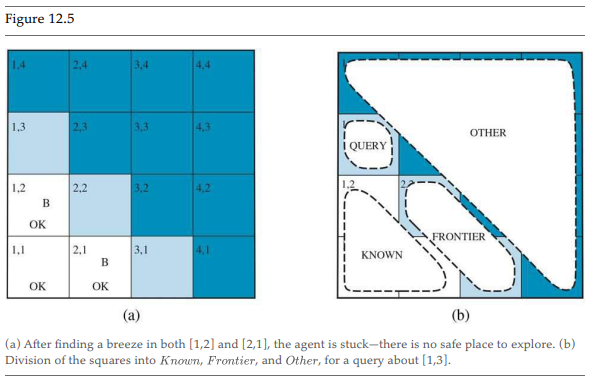

Probabilistic reasoning allows an agent to make accurate predictions in the **Wumpus World** even when logical inference is stuck. While logic can only conclude that the safety of a square is "unknown," probability quantifies the **degree of belief** that a pit exists, allowing for safer navigation.

### **1. The Foundation: Variables and Priors**
The model uses Boolean random variables: **$P_{i,j}$** (true if square $(i,j)$ has a pit) and **$B_{i,j}$** (true if it has a breeze). 
*   **Prior Probability:** Every square (except the start) has an independent **0.2 probability** of containing a pit.
*   **Sensor Model:** The probability of a breeze given a configuration of pits is **1** if it perfectly matches the rules (breezes only exist adjacent to pits) and **0** otherwise.

### **2. The Complexity Challenge and the "Frontier" Insight**
In a $4 \times 4$ grid, calculating the probability of a pit in a specific square originally requires summing over all 12 unknown squares ($2^{12} = 4,096$ terms), which grows exponentially with grid size. 
*   **The Insight:** Observed breezes are **conditionally independent** of distant "Other" squares once the status of the "Frontier" (unvisited squares adjacent to visited ones) is known.
*   **The Result:** The "Other" squares sum to 1 and disappear from the equation, reducing the calculation to only the **Frontier** variables. In a typical stuck scenario, this reduces the math from thousands of terms to just four.

### **3. The Calculation Process**
To find the probability of a pit in a query square like **(1,3)**, the agent:
1.  **Sums consistent models:** It identifies all combinations of the Frontier squares (e.g., (2,2) and (3,1)) that are logically consistent with the detected breezes.
2.  **Calculates Raw Totals:** It sums the probabilities of these consistent worlds for both the case where the query square is **true** and the case where it is **false**.
3.  **Normalizes:** It divides these raw totals by their sum to ensure the final probabilities add up to 1.

### **4. Predictive Results and Meaning**
Through this math, the agent discovers that squares logic viewed as identical are actually quite different:
*   **Square (1,3):** ~31% chance of a pit.
*   **Square (2,2):** ~86% chance of a pit.

These percentages represent a **degree of belief** grounded in the agent's current knowledge state. This process is mathematically **consistent** and **rational**; according to **de Finetti’s theorem**, any agent whose beliefs violate these probability axioms could be forced into bets where they are guaranteed to lose money. By following this "Standard Model" of AI, the agent ensures it always chooses the action that achieves the **maximum expected utility**.